# **1. Import Libraries**

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **2. Load Dataset**

In [38]:
# Step 1: Load Dataset
df = pd.read_excel("/content/Data Visualisation - COM7021 - [4566] Bakery- supporting document.xlsx")

# Step 2: Data Cleaning
df = df.drop_duplicates()
df.fillna(0, inplace=True)

#
df['Confectionary'] = df['Confectionary'].str.strip().str.title()

# Optional typo fix (recommended)
df['Confectionary'] = df['Confectionary'].replace({
    'Choclate Chunk': 'Chocolate Chunk'
})

# Create Profit column
df['Profit(£)'] = df['Revenue(£)'] - df['Cost(£)']
print(df.head())
print(df.info())

        Date    City Confectionary  Units Sold  Revenue(£)  Cost(£)  Profit(£)
0 2002-11-11  London       Biscuit      1118.0      5590.0   2459.6     3130.4
1 2002-07-05  London       Biscuit       708.0      3540.0   1557.6     1982.4
2 2001-10-31  London       Biscuit      1269.0      6345.0   2791.8     3553.2
3 2004-09-13  London       Biscuit      1631.0      8155.0   3588.2     4566.8
4 2004-03-10  London       Biscuit      2240.0     11200.0   4928.0     6272.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1001 non-null   datetime64[ns]
 1   City           1001 non-null   object        
 2   Confectionary  1001 non-null   object        
 3   Units Sold     1001 non-null   float64       
 4   Revenue(£)     1001 non-null   float64       
 5   Cost(£)        1001 non-null   float64       
 6   Profit(

# **3. Data Cleaning**

In [29]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df.fillna(0, inplace=True)

# Create Profit column (important for analysis)
df['Profit(£)'] = df['Revenue(£)'] - df['Cost(£)']

# **4. Basic Exploration**

In [30]:
print(df.describe())

# Profit by city
city_profit = df.groupby('City')['Profit(£)'].sum().sort_values(ascending=False)
print(city_profit)

# Profit by product
product_profit = df.groupby('Confectionary')['Profit(£)'].sum().sort_values(ascending=False)
print(product_profit)

                                Date   Units Sold    Revenue(£)       Cost(£)  \
count                           1001  1001.000000   1001.000000   1001.000000   
mean   2002-11-19 10:54:32.727272832  1625.201798   6786.034965   2794.834515   
min              2000-01-02 00:00:00     0.000000      0.000000      0.000000   
25%              2001-05-12 00:00:00   921.000000   2955.000000   1198.750000   
50%              2002-11-10 00:00:00  1520.000000   5885.000000   2428.500000   
75%              2004-04-25 00:00:00  2296.000000   9495.000000   3908.000000   
max              2005-12-28 00:00:00  4493.000000  23988.000000  10994.500000   
std                              NaN   881.721395   4722.478423   2081.723695   

          Profit(£)  
count   1001.000000  
mean    3991.200450  
min    -4745.400000  
25%     1857.500000  
50%     3460.800000  
75%     5452.500000  
max    13479.000000  
std     2714.133499  
City
Paris      933536.30
Napoli     911703.20
Seville    736433.00
Bonn

# **5. Visualisation 1  Profit by City**

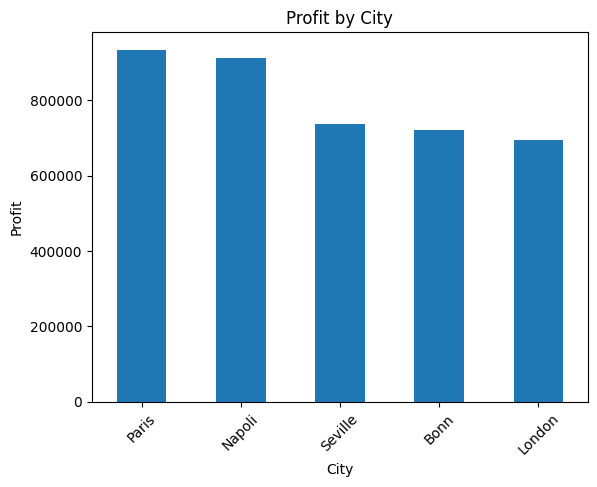

In [31]:
plt.figure()
city_profit.plot(kind='bar')
plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

# **6. Visualisation 2 - Profit by Product**

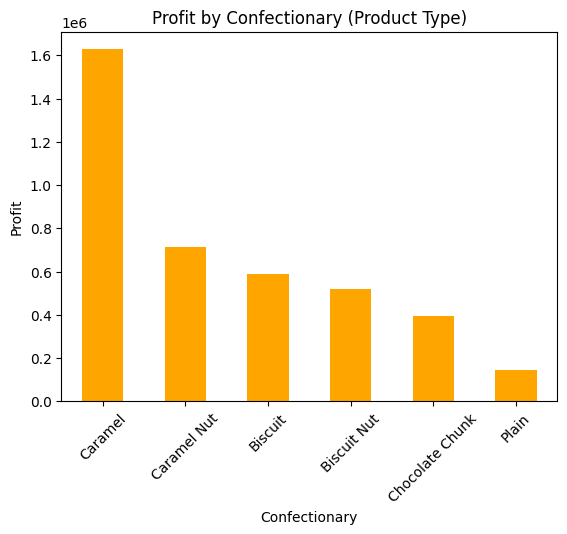

In [32]:
plt.figure()
product_profit.plot(kind='bar', color='orange')
plt.title("Profit by Confectionary (Product Type)")
plt.xlabel("Confectionary")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.show()

# **7. Visualisation 3 – Revenue vs Cost**

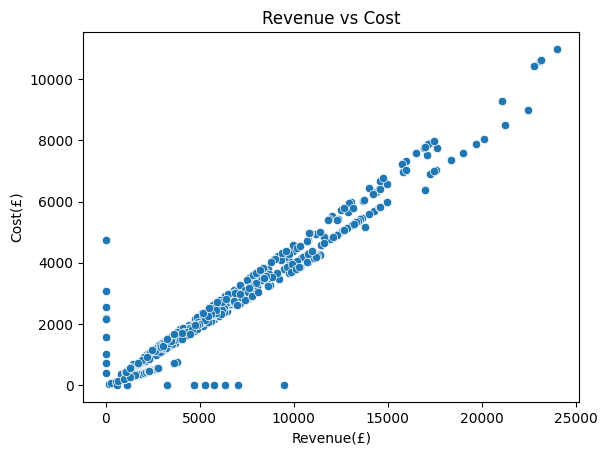

In [33]:
plt.figure()
sns.scatterplot(data=df, x='Revenue(£)', y='Cost(£)')
plt.title("Revenue vs Cost")
plt.show()

# **8. Visualisation 4 – Heatmap (Correlation)**

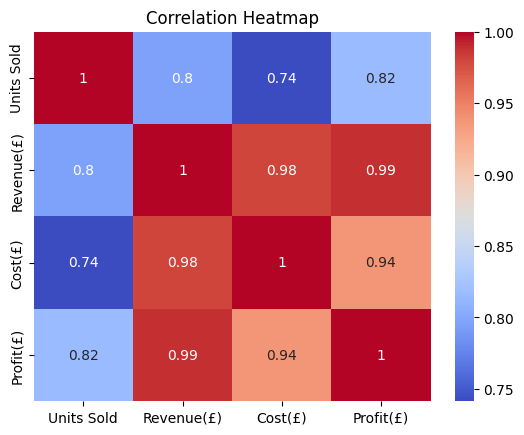

In [34]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **9. Visualisation 5 – Profit Trend Over Time**

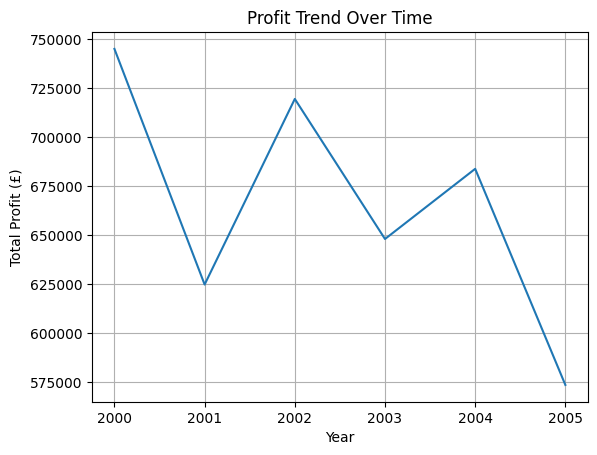

In [35]:
# Extract Year from Date
df['Year'] = df['Date'].dt.year

# Group by Year
year_profit = df.groupby('Year')['Profit(£)'].sum()

# Plot line chart
plt.figure()
year_profit.plot(kind='line')
plt.title("Profit Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Profit (£)")
plt.grid(True)
plt.show()

# **10. Plotly Interactive Revenue vs Cost by City**

In [36]:
import plotly.graph_objects as go

cities = df['City'].unique()

fig = go.Figure()

colors = {
    "London": "blue",
    "Paris": "red",
    "Bonn": "green",
    "Seville": "purple",
    "Napoli": "orange"
}

# Add traces
for city in cities:
    city_df = df[df['City'] == city]
    fig.add_trace(go.Scatter(
        x=city_df['Revenue(£)'],
        y=city_df['Cost(£)'],
        mode='markers',
        name=city,
        marker=dict(color=colors.get(city, "gray"))
    ))

# Dropdown buttons
buttons = []

buttons.append(dict(
    label="All Cities",
    method="update",
    args=[{"visible": [True]*len(cities)}]
))

for i, city in enumerate(cities):
    visible = [False]*len(cities)
    visible[i] = True

    buttons.append(dict(
        label=city,
        method="update",
        args=[{"visible": visible}]
    ))


fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=0.5,
        y=1.15,
        xanchor="center",
        yanchor="top"
    )]
)

# legend
fig.update_layout(
    legend=dict(
        x=1.05,
        y=1
    )
)

fig.update_layout(
    title="Interactive Revenue vs Cost by City",
    xaxis_title="Revenue (£)",
    yaxis_title="Cost (£)"
)

fig.show()

# **11. Plotly Dashboards**

In [41]:
import plotly.subplots as sp
import plotly.graph_objects as go

fig = sp.make_subplots(
    rows=2, cols=2,
    specs=[
        [{"type": "xy"}, {"type": "domain"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Profit by City",
        "Revenue by Confectionary (Product Type)",
        "Revenue vs Cost",
        "Profit Distribution"
    )
)

# 1. Profit by City (Bar) → NO LEGEND
city_profit = df.groupby('City')['Profit(£)'].sum()

fig.add_trace(
    go.Bar(
        x=city_profit.index,
        y=city_profit.values,
        marker=dict(color='steelblue'),
        showlegend=False
    ),
    row=1, col=1
)

# 2. Revenue by Confectionary (Pie)
product_rev = df.groupby('Confectionary')['Revenue(£)'].sum()

fig.add_trace(
    go.Pie(
    labels=product_rev.index,
    values=product_rev.values,
    textinfo='percent+label',
    showlegend=False
    ),
    row=1, col=2
)

# 3. Revenue vs Cost (Scatter by City)
for city in df['City'].unique():
    city_df = df[df['City'] == city]
    fig.add_trace(
        go.Scatter(
            x=city_df['Revenue(£)'],
            y=city_df['Cost(£)'],
            mode='markers',
            name=city,
            showlegend=True
        ),
        row=2, col=1
    )

# 4. Profit Distribution (Histogram)
fig.add_trace(
    go.Histogram(
        x=df['Profit(£)'],
        marker=dict(color='lightgreen'),
        showlegend=False
    ),
    row=2, col=2
)

# Layout Fixes
fig.update_layout(
    title="European Bakery Performance Dashboard (City & Confectionary Analysis)",
    legend=dict(
        x=1.05,
        y=1
    ),
    height=700
)

fig.show()
